# Process Echosounder Data
### Deeper Pro+ Bathymetry · Tide-Gauge Correction · GeoJSON Export

This notebook processes depth data collected with a **Deeper Pro+ echosounder**,
matches it to a **tide-gauge water-level record**, and exports the corrected
bathymetry as files ready to use in GIS software such as **QGIS** or **ArcGIS**.

---

## What this notebook does

| Step | What happens |
|------|--------------|
| 1 | Install libraries and connect Google Drive |
| 2 | Set the paths to your input files |
| 3 | Preview and check the input data |
| 4 | Configure column names |
| 5 | Set tide-gauge column names |
| 6 | Set processing and export options |
| 7 | Run the full processing workflow |
| 8 | Inspect and plot the results |

## What you need before you start

- The **scan CSV** exported from the Deeper app (e.g. `scan_data_20260621155157.csv`).
- A **tide-gauge CSV** file with water-level measurements
  (e.g. `GENOVA.csv` from the Italian tide-gauge network).
- The processing script **`bathymetry_tide_processing.py`** saved in a
  `scripts/` subfolder of your project folder on Google Drive.

## Recommended folder structure on Google Drive

```
Ground_truthing_bathy_habitat/
├── scripts/
│   └── bathymetry_tide_processing.py
├── Example data/
│   ├── Deeper_Pro/
│   │   └── scan_data_20260621155157.csv
│   └── Tide/
│       └── GENOVA.csv
└── Process_Echosounder_Data.ipynb
```

---

> **New to Colab?**  Run cells one at a time using the ▶ button on the left,
> or press **Shift + Enter** to run the current cell and move to the next one.
> Cells marked **✏️ EDIT HERE** require you to change a value before running.


## Step 1 · Install libraries and connect Google Drive

This cell does three things:

1. **Installs** the Python libraries that the workflow needs.
   This takes about 30 seconds the first time.
2. **Mounts** your Google Drive so the notebook can read and write your files.
   A permission dialog will appear — follow the prompts to authorise access.
3. **Sets** the project folder path and adds the `scripts/` subfolder to
   Python's import list so the processing script can be loaded in the next step.

> **✏️ EDIT HERE** — update `PROJECT_DIR` to match the location of your
> project folder on Google Drive.


In [2]:
# =============================================================================
# Step 1 · Install libraries and connect Google Drive
# =============================================================================

# Install required libraries.
# The -q flag keeps the output short. This only needs to run once per session.
!pip install -q gpxpy piexif pillow pandas matplotlib folium pyproj

from google.colab import drive
from pathlib import Path
import sys

# Mount Google Drive.
# After this runs, your Drive files will be accessible under /content/drive.
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# ─── ✏️ EDIT HERE ────────────────────────────────────────────────────────────
# Set this to the folder on your Google Drive that contains the scripts/ subfolder.
PROJECT_DIR = Path(
    "/content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat"
)
# ─────────────────────────────────────────────────────────────────────────────

SCRIPTS_DIR = PROJECT_DIR / "scripts"
SCRIPTS_DIR.mkdir(parents=True, exist_ok=True)

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

print(f"✅ Project folder : {PROJECT_DIR}")
print(f"   Scripts folder : {SCRIPTS_DIR}")
print(f"   Drive mounted  : /content/drive")


✅ Project folder : /content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat
   Scripts folder : /content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat/scripts
   Drive mounted  : /content/drive


## Step 2 · Set the paths to your input files

Point the notebook to your **Deeper scan CSV** and your **tide-gauge CSV**.

The output folder (`processed_outputs/`) is created automatically next to
the scan file — you do not need to create it yourself.

> **✏️ EDIT HERE** — update `SCAN_CSV` and `TIDE_CSV` to match your file locations.


In [5]:
# =============================================================================
# Step 2 · Set the paths to your input files
# =============================================================================

import os

# ─── ✏️ EDIT HERE ────────────────────────────────────────────────────────────
# Path to the Deeper Pro CSV exported from the Deeper app.
SCAN_CSV = Path(
    "/content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat/Example data/Deeper_Pro/scan_data_20260621155157.csv"
)

# Path to the tide-gauge CSV (e.g. downloaded from the Italian tide network).
TIDE_CSV = Path(
    "/content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat/Example data/Tide/GENOVA.csv"
)
# ─────────────────────────────────────────────────────────────────────────────

# The output folder is created automatically next to the scan file.
OUTPUT_DIR = SCAN_CSV.parent / "processed_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Check that the files exist before going further.
if not SCAN_CSV.exists():
    raise FileNotFoundError(f"Scan file not found:\n  {SCAN_CSV}")
if not TIDE_CSV.exists():
    raise FileNotFoundError(f"Tide-gauge file not found:\n  {TIDE_CSV}")

print("✅ Input files found")
print(f"   Scan CSV   : {SCAN_CSV.name}")
print(f"   Tide CSV   : {TIDE_CSV.name}")
print(f"   Output dir : {OUTPUT_DIR}")


✅ Input files found
   Scan CSV   : scan_data_20260621155157.csv
   Tide CSV   : GENOVA.csv
   Output dir : /content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat/Example data/Deeper_Pro/processed_outputs


## Step 3 · Preview and check the input data

Run this cell to display the first few rows of each file and to count how many
scan points have valid GPS coordinates.

You do not need to edit anything here — just read the output to make sure the
data looks correct before continuing.


In [6]:
# =============================================================================
# Step 3 · Preview and check the input data
# =============================================================================

import pandas as pd

# Read the first five rows of each file.
# sep=None tells pandas to detect the separator automatically
# (comma, semicolon, tab, etc.).
scan_preview = pd.read_csv(SCAN_CSV, sep=None, engine="python", nrows=5)
tide_preview = pd.read_csv(TIDE_CSV, sep=None, engine="python", nrows=5)

# Read the full scan file to count rows with and without GPS coordinates.
# The Deeper Pro records depth even when it cannot get a GPS fix,
# so the first rows often have no latitude/longitude — this is normal.
scan_full = pd.read_csv(SCAN_CSV, sep=None, engine="python")

n_total      = len(scan_full)
n_no_gps     = scan_full[["latitude", "longtitude"]].isna().any(axis=1).sum()
n_with_gps   = n_total - n_no_gps

print("Scan file summary")
print("-" * 40)
print(f"  Total rows         : {n_total:,}")
print(f"  Rows without GPS   : {n_no_gps:,}  ← will be removed during processing")
print(f"  Rows with GPS      : {n_with_gps:,}  ← will be kept")
print()
print("Scan columns:", list(scan_preview.columns))
display(scan_preview)

print()
print("Tide-gauge columns:", list(tide_preview.columns))
display(tide_preview)


Scan file summary
----------------------------------------
  Total rows         : 11,778
  Rows without GPS   : 10,852  ← will be removed during processing
  Rows with GPS      : 926  ← will be kept

Scan columns: ['latitude', 'longtitude', 'depth', 'temperature', 'time']


,latitude,longtitude,depth,temperature,time
0,NaN,NaN,0.781,29.0,1782049920508
1,NaN,NaN,0.791,29.0,1782049920859
2,NaN,NaN,0.812,29.0,1782049921059
3,NaN,NaN,0.812,29.0,1782049921610
4,NaN,NaN,0.791,29.0,1782049922018



Tide-gauge columns: ['DATE', 'TIME', 'HYDROMETRIC LEVEL']


,DATE,TIME,HYDROMETRIC LEVEL
0,2026-06-17,00:00,"0,156"
1,2026-06-17,00:10,"0,155"
2,2026-06-17,00:20,"0,134"
3,2026-06-17,00:30,"0,137"
4,2026-06-17,00:40,"0,136"


## Step 4 · Configure scan column names

Tell the notebook which columns in the scan file contain depth, time,
latitude, and longitude.

Use the column names shown in the **Scan columns** list printed above.

> The Deeper Pro exports a column called `longtitude` (note the typo —
> this is how the Deeper app writes it). The default below matches this.


In [7]:
# =============================================================================
# Step 4 · Configure scan column names
# =============================================================================

# ─── ✏️ EDIT HERE if your scan file uses different column names ──────────────

# Column containing the measured depth (in metres).
SCAN_DEPTH_COLUMN     = "depth"

# Column containing the acquisition time as a UNIX timestamp.
# For Deeper Pro exports, this is usually called "time".
SCAN_TIME_COLUMN      = "time"

# Columns containing GPS coordinates.
# Note: Deeper Pro exports "longtitude" (with the typo). Keep as-is.
SCAN_LATITUDE_COLUMN  = "latitude"
SCAN_LONGITUDE_COLUMN = "longtitude"

# UNIX timestamp unit.
# Leave as "auto" — the script will detect the correct unit automatically.
# Change only if you see incorrect dates in the output.
# Options: "auto", "s" (seconds), "ms" (milliseconds), "us" (microseconds)
SCAN_UNIX_UNIT = "auto"

# ─────────────────────────────────────────────────────────────────────────────

print("Scan column settings")
print("-" * 40)
print(f"  Depth column      : {SCAN_DEPTH_COLUMN}")
print(f"  Time column       : {SCAN_TIME_COLUMN}")
print(f"  Latitude column   : {SCAN_LATITUDE_COLUMN}")
print(f"  Longitude column  : {SCAN_LONGITUDE_COLUMN}")
print(f"  UNIX time unit    : {SCAN_UNIX_UNIT}")


Scan column settings
----------------------------------------
  Depth column      : depth
  Time column       : time
  Latitude column   : latitude
  Longitude column  : longtitude
  UNIX time unit    : auto


## Step 5 · Configure tide-gauge column names

Tell the notebook which columns in the tide-gauge file contain the
water-level measurements and the date/time information.

The GENOVA tide-gauge file uses **two separate columns** for date and time.
If your tide file combines date and time into a single column, follow the
**Case B** instructions in the comments below.


In [8]:
# =============================================================================
# Step 5 · Configure tide-gauge column names
# =============================================================================

# Column containing the water-level measurement (in metres above datum).
# ─── ✏️ EDIT if your file uses a different column name ───────────────────────
TIDE_WATER_LEVEL_COLUMN = "HYDROMETRIC LEVEL"

# ─────────────────────────────────────────────────────────────────────────────
# CASE A — date and time are in two separate columns (e.g. GENOVA.csv)
# ─────────────────────────────────────────────────────────────────────────────
# ✏️ EDIT the column names below if your file uses different names.
TIDE_DATE_COLUMN     = "DATE"
TIDE_TIME_COLUMN     = "TIME"
TIDE_DATETIME_COLUMN = None     # Leave as None for Case A

# ─────────────────────────────────────────────────────────────────────────────
# CASE B — date and time are in a single combined column
# ─────────────────────────────────────────────────────────────────────────────
# If your tide file has one column such as "DATETIME", comment out the three
# lines above and uncomment these three lines instead:
#
# TIDE_DATE_COLUMN     = None
# TIDE_TIME_COLUMN     = None
# TIDE_DATETIME_COLUMN = "DATETIME"   # ← replace with your column name

# ─────────────────────────────────────────────────────────────────────────────
# Advanced options — leave as None unless you have parsing problems
# ─────────────────────────────────────────────────────────────────────────────

# Explicit date format (optional).
# Example for day/month/year: TIDE_DATETIME_FORMAT = "%d/%m/%Y %H:%M:%S"
TIDE_DATETIME_FORMAT = None

# Date parsing convention (optional).
# Set True if your dates are written as day/month/year (European style).
# Set False for month/day/year (US style). Leave None to auto-detect.
TIDE_DAYFIRST = None

# Timezone (optional).
# Example: TIMEZONE = "Europe/Rome"
# Leave None if your scan and tide files are already in the same time reference.
TIMEZONE = None

print("Tide-gauge column settings")
print("-" * 40)
print(f"  Water-level column : {TIDE_WATER_LEVEL_COLUMN}")
print(f"  Date column        : {TIDE_DATE_COLUMN}")
print(f"  Time column        : {TIDE_TIME_COLUMN}")
print(f"  Datetime column    : {TIDE_DATETIME_COLUMN}")
print(f"  Datetime format    : {TIDE_DATETIME_FORMAT}")
print(f"  Day-first parsing  : {TIDE_DAYFIRST}")
print(f"  Timezone           : {TIMEZONE}")


Tide-gauge column settings
----------------------------------------
  Water-level column : HYDROMETRIC LEVEL
  Date column        : DATE
  Time column        : TIME
  Datetime column    : None
  Datetime format    : None
  Day-first parsing  : None
  Timezone           : None


## Step 6 · Set processing and export options

This cell controls how scan points are matched to tide measurements,
how the data are split into training and validation sets, and which
output formats are exported.

The defaults work well for most surveys. You only need to change
values if your tide gauge logs at a very different frequency or if
you need a different train/validation ratio.


In [9]:
# =============================================================================
# Step 6 · Set processing and export options
# =============================================================================

# ── Tide matching ─────────────────────────────────────────────────────────────

# Method used to assign a water level to each scan point.
#
#   "interpolate" — estimate the tide level between measurements by linear
#                   interpolation. Best when tide data are coarser than scan
#                   data (e.g. tide every 10 min, scan every second).
#   "nearest"     — use the nearest tide measurement in time.
MATCH_METHOD = "interpolate"

# Maximum allowed time gap between a scan point and the nearest tide measurement.
# Scan points with no tide data within this window receive no tide correction.
#
# Common values:
#   "5min"  — tight match, use when tide data are frequent
#   "15min" — good default for 10-minute tide gauges
#   "1h"    — very permissive, use only for hourly tide data
MATCH_TOLERANCE = "15min"

# ── Training / validation split ───────────────────────────────────────────────

# Fraction of matched data points assigned to training (0.0 – 1.0).
# The remainder is assigned to validation.
# Example: 0.70 → 70% training, 30% validation.
TRAIN_FRACTION = 0.70

# Random seed. Keep fixed for reproducible splits.
RANDOM_SEED = 42

# If True, points are randomly shuffled before splitting.
# If False, the split follows the original survey order.
SHUFFLE_SPLIT = True

# ── Export formats ────────────────────────────────────────────────────────────

# Export GeoJSON files in geographic coordinates (WGS 84 / EPSG:4326).
# These can be opened directly in QGIS, Google Earth, or any web map.
EXPORT_GEOJSON = True

# Also export GeoJSON files in UTM metric coordinates.
# Useful for QGIS analyses that require distances in metres.
EXPORT_UTM_GEOJSON = True

# UTM EPSG code. Leave as None to detect automatically from the scan coordinates.
# Example for the Ligurian coast: UTM_EPSG = 32632  (UTM zone 32N)
UTM_EPSG = None

print("Processing settings")
print("-" * 40)
print(f"  Match method        : {MATCH_METHOD}")
print(f"  Match tolerance     : {MATCH_TOLERANCE}")
print(f"  Training fraction   : {TRAIN_FRACTION:.0%}")
print(f"  Validation fraction : {1 - TRAIN_FRACTION:.0%}")
print(f"  Random seed         : {RANDOM_SEED}")
print(f"  Shuffle split       : {SHUFFLE_SPLIT}")
print(f"  Export GeoJSON      : {EXPORT_GEOJSON}")
print(f"  Export UTM GeoJSON  : {EXPORT_UTM_GEOJSON}")
print(f"  Manual UTM EPSG     : {UTM_EPSG}")


Processing settings
----------------------------------------
  Match method        : interpolate
  Match tolerance     : 15min
  Training fraction   : 70%
  Validation fraction : 30%
  Random seed         : 42
  Shuffle split       : True
  Export GeoJSON      : True
  Export UTM GeoJSON  : True
  Manual UTM EPSG     : None


## Step 7 · Run the processing workflow

This cell runs the full pipeline in one go.

What happens under the hood:

1. Load and clean the scan data (rows without GPS are removed).
2. Load and parse the tide-gauge data.
3. Match each scan point to a tide water-level value.
4. Apply the **tide correction**: `corrected_depth = depth + water_level`.
5. Split the matched dataset into training and validation sets.
6. Export CSV and GeoJSON files to the `processed_outputs/` folder.

A summary is printed at the end showing how many points were matched
and where the output files are saved.


In [10]:
# =============================================================================
# Step 7 · Run the processing workflow
# =============================================================================

import importlib
import bathymetry_tide_processing
importlib.reload(bathymetry_tide_processing)
from bathymetry_tide_processing import (
    process_bathymetry_with_tide,
    print_processing_summary,
)

results = process_bathymetry_with_tide(
    scan_csv  = SCAN_CSV,
    tide_csv  = TIDE_CSV,
    output_dir = OUTPUT_DIR,

    # Scan column names (set in Step 4)
    scan_depth_column     = SCAN_DEPTH_COLUMN,
    scan_time_column      = SCAN_TIME_COLUMN,
    scan_latitude_column  = SCAN_LATITUDE_COLUMN,
    scan_longitude_column = SCAN_LONGITUDE_COLUMN,
    scan_unix_unit        = SCAN_UNIX_UNIT,

    # Tide column names (set in Step 5)
    tide_water_level_column = TIDE_WATER_LEVEL_COLUMN,
    tide_date_column        = TIDE_DATE_COLUMN,
    tide_time_column        = TIDE_TIME_COLUMN,
    tide_datetime_column    = TIDE_DATETIME_COLUMN,
    tide_datetime_format    = TIDE_DATETIME_FORMAT,
    tide_dayfirst           = TIDE_DAYFIRST,
    timezone                = TIMEZONE,

    # Processing settings (set in Step 6)
    match_method      = MATCH_METHOD,
    match_tolerance   = MATCH_TOLERANCE,
    train_fraction    = TRAIN_FRACTION,
    random_seed       = RANDOM_SEED,
    shuffle_split     = SHUFFLE_SPLIT,
    export_geojson    = EXPORT_GEOJSON,
    export_utm_geojson = EXPORT_UTM_GEOJSON,
    utm_epsg          = UTM_EPSG,

    drop_missing_coordinates = True,
)

# Unpack the main output dataframes for use in the next step.
scan_df       = results["scan"]
tide_df       = results["tide"]
merged        = results["merged"]
training      = results["training"]
validation    = results["validation"]

# Print the processing summary.
print_processing_summary(results["summary"])

print()
print("Output files")
print("-" * 40)
for key, path in results["output_files"].items():
    if key != "utm_epsg":
        print(f"  {key:<30} {path.name}")


Processing summary
------------------
Scan points after cleaning:   926
Tide points after cleaning:   911
Total merged scan points:     926
Matched tide points:          926 (100.00%)
Unmatched scan points:        0 (0.00%)

Training points:              648 (69.98% of matched)
Validation points:            278 (30.02% of matched)

Scan time range:              2026-06-21 13:52:24+00:00  ->  2026-06-21 14:08:09+00:00
Tide time range:              2026-06-17 00:00:00  ->  2026-06-23 07:40:00

Output files
----------------------------------------
  merged_csv                     merged.csv
  training_csv                   training.csv
  validation_csv                 validation.csv
  merged_geojson_wgs84           merged_wgs84.geojson
  training_geojson_wgs84         training_wgs84.geojson
  validation_geojson_wgs84       validation_wgs84.geojson
  merged_geojson_utm             merged_utm_EPSG32632.geojson
  training_geojson_utm           training_utm_EPSG32632.geojson
  validation_geoj

## Step 8 · Inspect and plot the results

Run these cells to visually check the outputs.

The first plot shows depth versus time for the survey.
The second plot shows the tide water level over the same period.
The third plot shows the distribution of tide-corrected depths.


In [11]:
# =============================================================================
# Step 8a · Preview the merged dataset
# =============================================================================

print(f"Merged dataset: {len(merged):,} rows, {len(merged.columns)} columns")
print()
merged.head(10)


Merged dataset: 926 rows, 10 columns



,latitude,longtitude,depth,temperature,time,timestamp,longitude,water_level,nearest_tide_timestamp,tide_correction
0,44.161667,8.334807,0.978,0.0,1782049944000,2026-06-21 13:52:24,8.334807,0.070975,2026-06-21 13:50:00,1.048975
1,44.161677,8.334822,0.760,0.0,1782049945000,2026-06-21 13:52:25,8.334822,0.070950,2026-06-21 13:50:00,0.830950
2,44.161693,8.334855,0.957,0.0,1782049947000,2026-06-21 13:52:27,8.334855,0.070925,2026-06-21 13:50:00,1.027925
3,44.161702,8.334858,0.978,0.0,1782049948000,2026-06-21 13:52:28,8.334858,0.070900,2026-06-21 13:50:00,1.048900
4,44.161712,8.334858,0.937,0.0,1782049949000,2026-06-21 13:52:29,8.334858,0.070874,2026-06-21 13:50:00,1.007874
5,44.161710,8.334857,0.937,0.0,1782049950000,2026-06-21 13:52:30,8.334857,0.070849,2026-06-21 13:50:00,1.007849
6,44.161753,8.334937,0.739,0.0,1782049953000,2026-06-21 13:52:33,8.334937,0.070824,2026-06-21 13:50:00,0.809824
7,44.161752,8.334932,0.874,0.0,1782049954000,2026-06-21 13:52:34,8.334932,0.070799,2026-06-21 13:50:00,0.944799
8,44.161753,8.334923,0.999,0.0,1782049955000,2026-06-21 13:52:35,8.334923,0.070774,2026-06-21 13:50:00,1.069774
9,44.161758,8.334917,1.124,0.0,1782049956000,2026-06-21 13:52:36,8.334917,0.070749,2026-06-21 13:50:00,1.194749


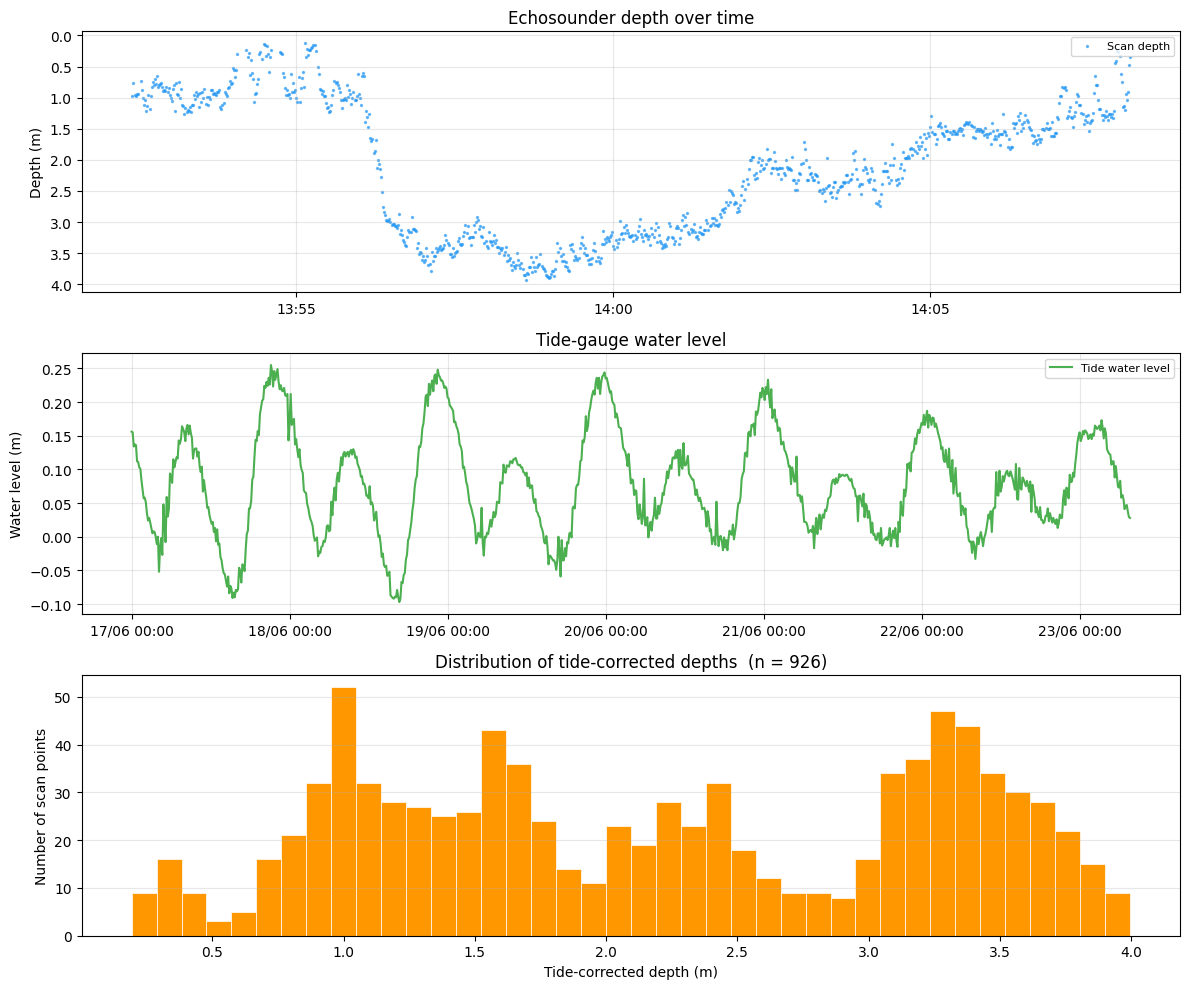


Tide-corrected depth statistics
-----------------------------------
count    926.000000
mean       2.190767
std        1.039522
min        0.192333
25%        1.278000
50%        2.173000
75%        3.234000
max        3.996110


In [12]:
# =============================================================================
# Step 8b · Plot depth profile and tide water level
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

# ── Plot 1: raw depth vs time ─────────────────────────────────────────────
ax = axes[0]
ax.scatter(
    merged["timestamp"], merged["depth"],
    s=2, color="#2196F3", alpha=0.6, label="Scan depth"
)
ax.set_ylabel("Depth (m)")
ax.set_title("Echosounder depth over time")
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)

# ── Plot 2: tide water level vs time ─────────────────────────────────────
ax = axes[1]
ax.plot(
    tide_df["timestamp"], tide_df["water_level"],
    color="#4CAF50", linewidth=1.5, label="Tide water level"
)
ax.set_ylabel("Water level (m)")
ax.set_title("Tide-gauge water level")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)

# ── Plot 3: tide-corrected depth distribution ─────────────────────────────
ax = axes[2]
valid = merged["tide_correction"].dropna()
ax.hist(valid, bins=40, color="#FF9800", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Tide-corrected depth (m)")
ax.set_ylabel("Number of scan points")
ax.set_title(f"Distribution of tide-corrected depths  (n = {len(valid):,})")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"\nTide-corrected depth statistics")
print("-" * 35)
print(valid.describe().to_string())


In [13]:
# =============================================================================
# Step 8c · Interactive map of scan points
# =============================================================================

import json
import folium

# Use the merged dataset — keep only rows with valid coordinates.
map_data = merged.dropna(subset=["latitude", "longitude"]).copy()

if len(map_data) == 0:
    print("No georeferenced scan points to display.")
else:
    center_lat = map_data["latitude"].mean()
    center_lon = map_data["longitude"].mean()

    scan_map = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=16,
        tiles="OpenStreetMap",
    )

    # Add scan points coloured by depth.
    for _, row in map_data.iterrows():
        depth_val = row.get("depth", None)
        popup_html = (
            f"<b>Depth:</b> {row.get('depth', 'n/a'):.2f} m<br>"
            f"<b>Tide correction:</b> {row.get('tide_correction', 'n/a')}<br>"
            f"<b>Water level:</b> {row.get('water_level', 'n/a')}<br>"
            f"<b>Time:</b> {row.get('timestamp', 'n/a')}"
        )
        folium.CircleMarker(
            location=[row["latitude"], row["longitude"]],
            radius=3,
            color="#2196F3",
            fill=True,
            fill_opacity=0.7,
            popup=folium.Popup(popup_html, max_width=260),
        ).add_to(scan_map)

    folium.LayerControl().add_to(scan_map)
    print(f"Showing {len(map_data):,} georeferenced scan points.")
    display(scan_map)


Showing 926 georeferenced scan points.
